In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

Начинаю расчет...
Расчет окончен.


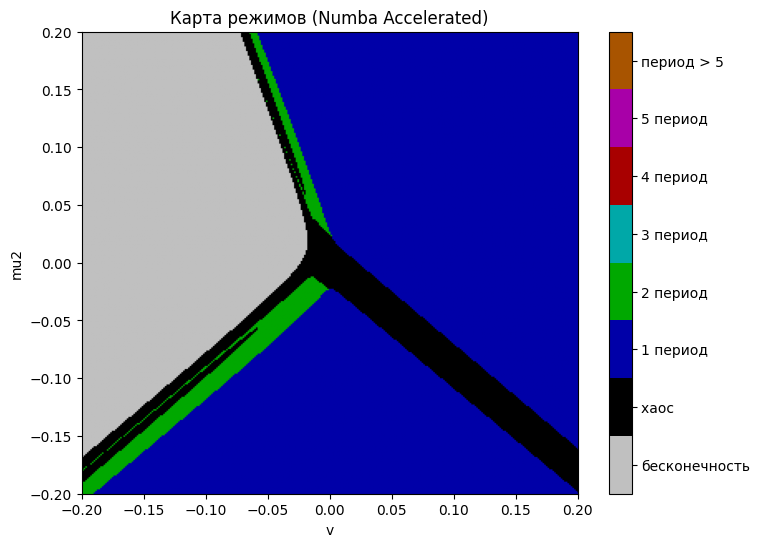

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from numba import njit  # <--- Импортируем магию

# 1. Оптимизируем функцию поиска периода с помощью Numba
@njit
def detect_period_fast(arr, max_period=20, tol=1e-6):
    n = len(arr)
    # Numba отлично оптимизирует циклы, поэтому range здесь работает очень быстро
    for p in range(1, min(max_period, n // 2) + 1):
        # Ручная проверка allclose для скорости внутри Numba
        is_periodic = True
        for i in range(n - p):
            if abs(arr[i] - arr[i + p]) > tol:
                is_periodic = False
                break
        if is_periodic:
            return p
    return 0 # Возвращаем 0 вместо None, так как Numba любит числа (0 будет означать хаос)

# 2. вся тяжелая логика в отдельной функции под декоратор @njit
@njit
def compute_regime_map(u1, u2, v_vals, mu2_vals, N_trans, N_iter, x0, y0):
    rows = len(mu2_vals)
    cols = len(v_vals)
    # Создаем карту сразу нужного размера
    regime_map = np.full((rows, cols), -1, dtype=np.int32)

    #  выделяем память под буфер для анализа (чтобы не делать append)
    y_vals = np.empty(N_iter, dtype=np.float64)

    for i in range(rows):
        mu2 = mu2_vals[i]
        alpha_tilde = (1 + mu2) / ((1 - u1) * (1 - u2))

        for j in range(cols):
            v = v_vals[j]
            x, y = x0, y0

            is_overflow = False

            # --- Прогрев ---
            for _ in range(N_trans):
                x_new = alpha_tilde * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new

                # Быстрая проверка на переполнение без try-except
                if abs(x) > 1e10 or abs(y) > 1e10: # 1e10 достаточно большое число
                    is_overflow = True
                    break

            if is_overflow:
                regime_map[i, j] = -1
                continue

            # --- Сбор данных ---
            for k in range(N_iter):
                x_new = alpha_tilde * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new

                if abs(x) > 1e10 or abs(y) > 1e10:
                    is_overflow = True
                    break

                y_vals[k] = y # Заполняем массив по индексу (быстрее append)

            if is_overflow:
                regime_map[i, j] = -1
            else:
                # Анализ
                p = detect_period_fast(y_vals, max_period=20, tol=1e-6)

                if p == 0:
                    regime_map[i, j] = 0  # Хаос
                elif p <= 5:
                    regime_map[i, j] = p  # Период 1-5
                else:
                    regime_map[i, j] = 6  # Период > 5

    return regime_map

# ---------------------
# Параметры и сетка
# ---------------------
u1 = 0.2
u2 = 0.1
x0, y0 = 0.1, 0.1

v_vals = np.linspace(-0.2, 0.2, 300)
mu2_vals = np.linspace(-0.2, 0.2, 300)

N_trans = 500
N_iter = 50

# ЗАПУСК РАСЧЕТА (Теперь это одна быстрая строка)
print("Начинаю расчет...")
regime_map = compute_regime_map(u1, u2, v_vals, mu2_vals, N_trans, N_iter, x0, y0)
print("Расчет окончен.")

# ---------------------
# Визуализация (Тут всё без изменений, кроме my_vmin/vmax логики)
# ---------------------
color_map = {
    -1: '#C0C0C0',   # бесконечность
     0: '#000000',   # хаос
     1: '#0000A8',   # 1 период
     2: '#00A800',   # 2 период
     3: '#00A8A8',   # 3 период
     4: '#A80000',   # 4 период
     5: '#A800A8',   # 5 период
     6: '#A85400',   # >5 период
}

label_map = {
    -1: 'бесконечность',
     0: 'хаос ',
     1: '1 период',
     2: '2 период',
     3: '3 период',
     4: '4 период',
     5: '5 период',
     6: 'период > 5',
}

keys = sorted(color_map.keys())
colors = [color_map[k] for k in keys]
cmap = ListedColormap(colors)

my_vmin = keys[0] - 0.5
my_vmax = keys[-1] + 0.5

plt.figure(figsize=(8, 6))
plt.imshow(
    regime_map,
    extent=[v_vals[0], v_vals[-1], mu2_vals[0], mu2_vals[-1]],
    origin='lower',
    aspect='auto',
    cmap=cmap,
    vmin=my_vmin,
    vmax=my_vmax
)

cbar = plt.colorbar(ticks=keys)
cbar.ax.set_yticklabels([label_map[k] for k in keys])

plt.xlabel('v')
plt.ylabel('mu2')
plt.title('Карта режимов (Numba Accelerated)')
plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from numba import njit

# =========================================================
# 1. ВНУТРЕННЯЯ ЛОГИКА (Numba) - БЕЗ ИЗМЕНЕНИЙ
# =========================================================
@njit
def detect_period_fast(arr, max_period=20, tol=1e-6):
    n = len(arr)
    for p in range(1, min(max_period, n // 2) + 1):
        is_periodic = True
        for i in range(n - p):
            if abs(arr[i] - arr[i + p]) > tol:
                is_periodic = False
                break
        if is_periodic:
            return p
    return 0

@njit
def compute_regime_map_internal(u1, u2, v_vals, mu2_vals, N_trans, N_iter, x0, y0):
    rows = len(mu2_vals)
    cols = len(v_vals)
    regime_map = np.full((rows, cols), -1, dtype=np.int32)
    y_vals = np.empty(N_iter, dtype=np.float64)

    for i in range(rows):
        mu2 = mu2_vals[i]
        denom = (1 - u1) * (1 - u2)
        if abs(denom) < 1e-9:
             alpha_tilde = 0.0
        else:
             alpha_tilde = (1 + mu2) / denom

        for j in range(cols):
            v = v_vals[j]
            x, y = x0, y0
            is_overflow = False

            # Прогрев
            for _ in range(N_trans):
                x_new = alpha_tilde * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if abs(x) > 1e10 or abs(y) > 1e10:
                    is_overflow = True
                    break

            if is_overflow:
                regime_map[i, j] = -1
                continue

            # Сбор данных
            for k in range(N_iter):
                x_new = alpha_tilde * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if abs(x) > 1e10 or abs(y) > 1e10:
                    is_overflow = True
                    break
                y_vals[k] = y

            if is_overflow:
                regime_map[i, j] = -1
            else:
                p = detect_period_fast(y_vals, max_period=20, tol=1e-6)
                if p == 0:
                    regime_map[i, j] = 0
                elif p <= 5:
                    regime_map[i, j] = p
                else:
                    regime_map[i, j] = 6

    return regime_map

# =========================================================
# 2. ФУНКЦИЯ-ОБЕРТКА (С НОВЫМИ ПАРАМЕТРАМИ)
# =========================================================
def plot_regime_map(
    u1, u2, x, y,          # <-- Ваши главные параметры теперь тут
    v_range=(-0.2, 0.2),   # Диапазон оси X
    mu2_range=(-0.2, 0.2), # Диапазон оси Y
    resolution=300,        # Качество картинки
    N_trans=1000,          # Длительность прогрева
    N_iter=100,            # Длительность анализа
    figsize=(8, 6)
):
    """
    Строит карту режимов для заданных u1, u2 и начальных условий x, y.
    """

    # 1. Подготовка сеток
    v_vals = np.linspace(v_range[0], v_range[1], resolution)
    mu2_vals = np.linspace(mu2_range[0], mu2_range[1], resolution)

    print(f"Расчет для u1={u1}, u2={u2}, start=({x}, {y})...")

    # 2. Вызов быстрого ядра (передаем ваши x, y как x0, y0 внутрь)
    map_data = compute_regime_map_internal(u1, u2, v_vals, mu2_vals, N_trans, N_iter, x, y)

    # 3. Рисование (без изменений логики отображения)
    color_map = {
        -1: '#E0E0E0', 0: '#000000', 1: '#0000A8', 2: '#00A800',
        3: '#00A8A8', 4: '#A80000', 5: '#A800A8', 6: '#FFA500'
    }
    label_map = {-1: 'Убегает на беск.', 0: 'Хаос', 1: 'период-1', 2: 'период-2', 3: 'период-3', 4: 'период-4', 5: 'период-5', 6: 'период > 5'}
    keys = sorted(color_map.keys())
    cmap = ListedColormap([color_map[k] for k in keys])

    plt.figure(figsize=figsize)
    plt.imshow(
        map_data,
        extent=[v_range[0], v_range[1], mu2_range[0], mu2_range[1]],
        origin='lower', aspect='auto', cmap=cmap,
        vmin=keys[0] - 0.5, vmax=keys[-1] + 0.5
    )

    cbar = plt.colorbar(ticks=keys)
    cbar.ax.set_yticklabels([label_map[k] for k in keys])

    plt.xlabel('v')
    plt.ylabel('mu2')
    plt.title(f'Карта режимов ($u_1={u1}, u_2={u2}, x_0={x}, y_0={y}$)')
    plt.tight_layout()
    plt.show()






Расчет для u1=0.97, u2=0.6, start=(0.3, 0.6)...


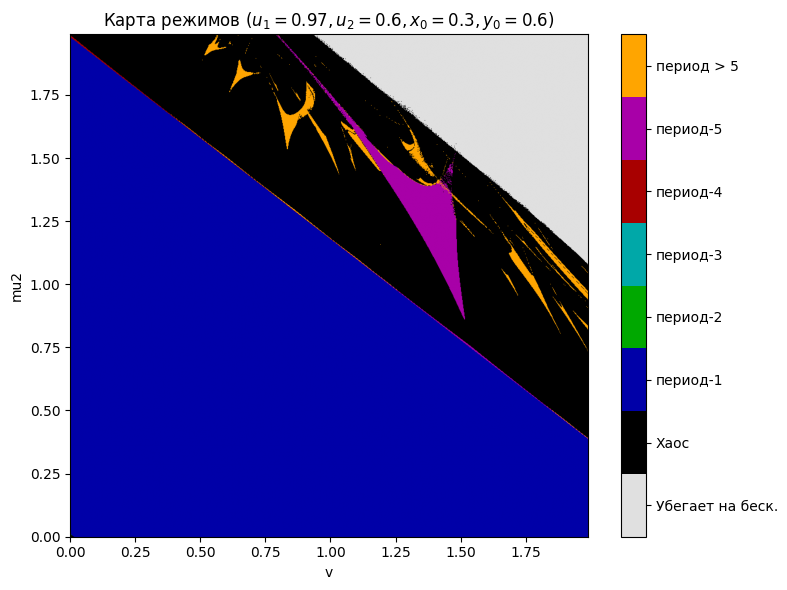

In [47]:
plot_regime_map(u1=0.97, u2=0.6, x=0.3, y=0.6, v_range=(0, 1.99), mu2_range = (0, 1.99),resolution=900)


Расчет для u1=0.97, u2=0.6, start=(0.3, 0.6)...


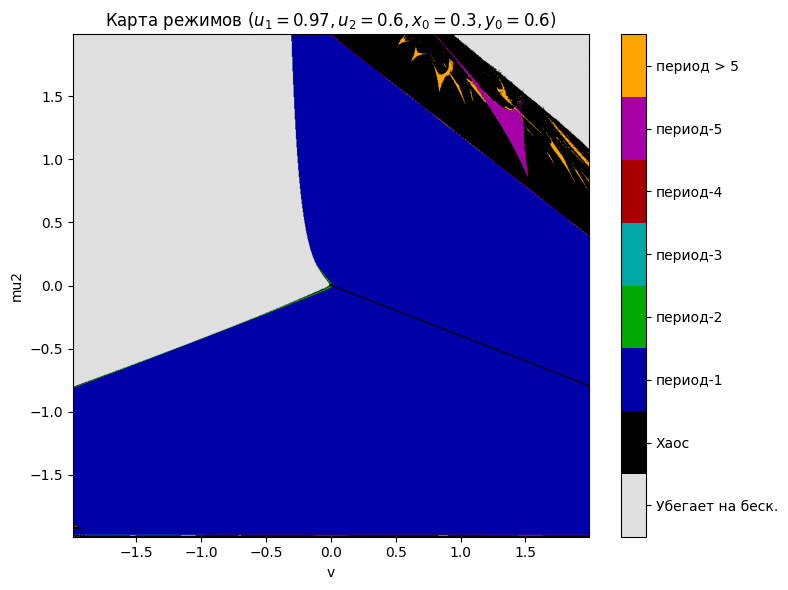

In [44]:
plot_regime_map(u1=0.97, u2=0.6, x=0.3, y=0.6, v_range=(-1.99, 1.99), mu2_range = (-1.99, 1.99),resolution=900)


Расчет для u1=0.97, u2=0.9, start=(0.3, 0.6)...


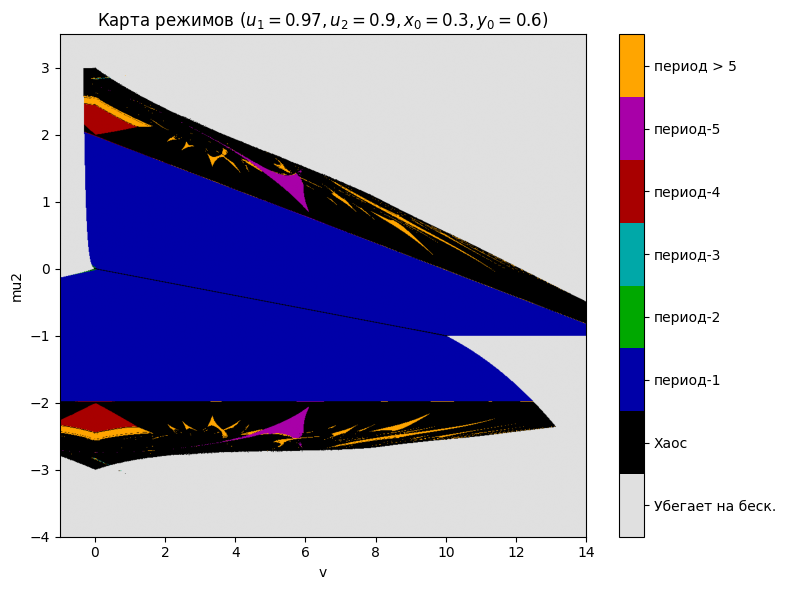

In [61]:
plot_regime_map(u1=0.97, u2=0.9, x=0.3, y=0.6, v_range=(-1, 14), mu2_range = (-4, 3.5),resolution=900)


Расчет для u1=0.97, u2=0.6, start=(0.3, 0.6)...


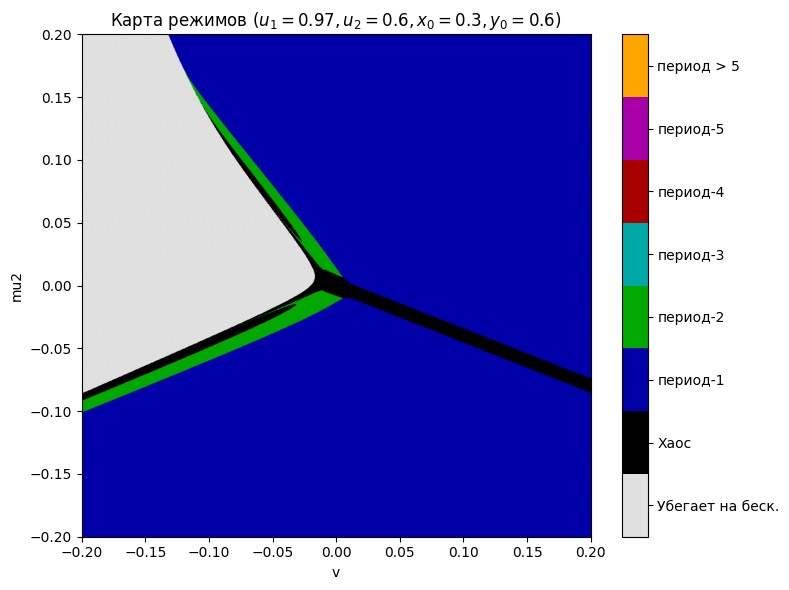

In [72]:
plot_regime_map(u1=0.97, u2=0.6, x=0.3, y=0.6, v_range=(-0.2, 0.2), mu2_range = (-0.2, 0.2),resolution=900)
